## Apresentação ✒️

Notebook destinado ao estudo e demonstração de prompt engineering, segundo uma concepção de redução de entropia. Entropia é o conceito presente na física, em especial, na termodinâmica trazida pelo físico Ludwig Boltzmann, a qual busca compreender o estado de agregação dos objetos num sístema físico qualquer. Com base nela, permite entender qual sistema físico pode apresentar maior desordenação em detrimento de outros e assim por diante. Por exemplo, uma vez que os elementos químicos presentes no estado físico gasoso estão mais dispersos, quando comparados se estivessem no estado líquido ou sólido, compreende-se que apresentam maior entropia, tendo em vista que estão menos agregados entre si e, portanto, mais dispersos, oferecendo maior nível de desordenação. 

- Em termos de equação a entropia é dado por : $S=klnW$

Contudo, a partir de uma nova perspectiva trazida por Claude Shannon - matemático e engeheiro elétrico - a entropia pôde também ser compreendida não apenas como uma medida que busca compreender o nível de desordenação de um sistema físico, mas também o nível de informação contida em um conjunto de estudo, em função do seu nível de incerteza associado, na forma em que quanto maior for o nível dessa, maior será o nível de informação necessária para a sua apreensão.

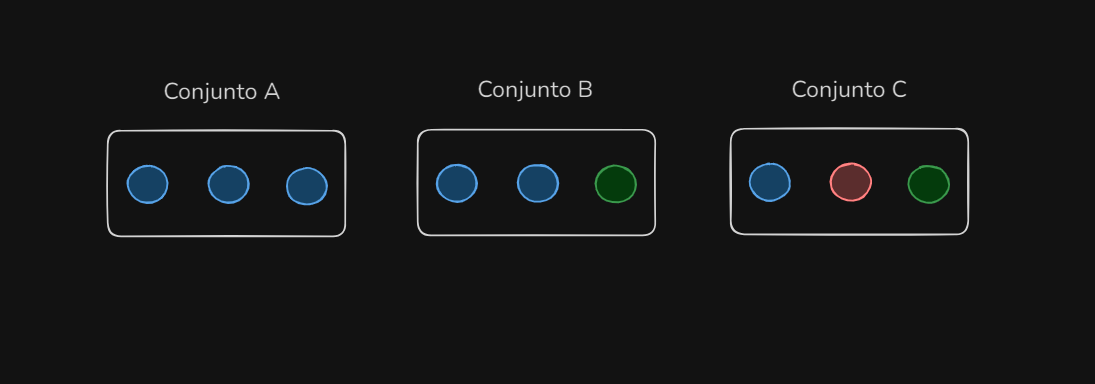

A imagem acima permite compreender de forma visual e lúdica a nova perspectiva proposta por Shannon, com base nos conjuntos existentes. Se eu te pedisse para selecionar ao acaso um dos circulos em cada um dos conjuntos, qual deles você teria maior certeza e menor, hierarquicamente, de encontrar o círculo azul ? Ceteris paribus (tudo o mais constante), o conjunto A é aquele que apresentaria maior certeza na seleção, sendo seguido pelo conjunto B e C, respectivamente. Ou seja, no conjunto A não haveria dúvida de que o círculo azul seria escolhido - o que significa que não há incerteza latente e, portanto, informação adicional alguma, apresentando menor entropia.

Em virtude disso, pode-se colocar em síntese que a entropia, por Shannon, também pode ser compreendida como a medida utilizada para mensurar a quantidade de informação necessária para descrever um conjunto de eventos possíveis, formalizada através da seguinte equação : 

$H = - \sum_{i} p_i \log_2 p_i$

**Em que:**

$pi$ - probabilidade da ocorrência do evento. 

A equação permite compreender dois cenários importantes :

- Se um evento tem a probabilidade de 1, então a sua entropia é zero (não há incerteza, o caso do conjunto A)
- Se um evento tem eventos equiprováveis, a entropia é máxima (ocorre o máximo de incerteza, como no caso do conjunto C)

Trazendo para o contexto de prompt engineering, a entropia pode ser compreendida em relação aos possíveis tokens que podem ser selecionados para a inscrição de um novo token em função dos tokens anteriores, com base num universo determinado. Para compreender melhor essa consideração, faz-se necessário estudar como é construída a arquitetura de decoder, camada utilizada para o desenvolvimento de modelos auto regressivos, como o ChatGPT, Gemini, Llama e afins, principalmente em como se dá o processo da geração de novos tokens por parte do modelo, o qual ocorre mediante à inserção do token mais provável, dentre os possíveis presentes no universo de possbilidade em função dos tokens anteriores. 

**Esquematicamente :** 

Esquematicamente, tal relação pode ser representada seguindo a seguinte notação, de modo que ela busca representar o caráter condicional existente do token gerado em função dos anteriores. 

`P( token n | token x1 + token x2 + ... token n-1)`

**Visualmente :**

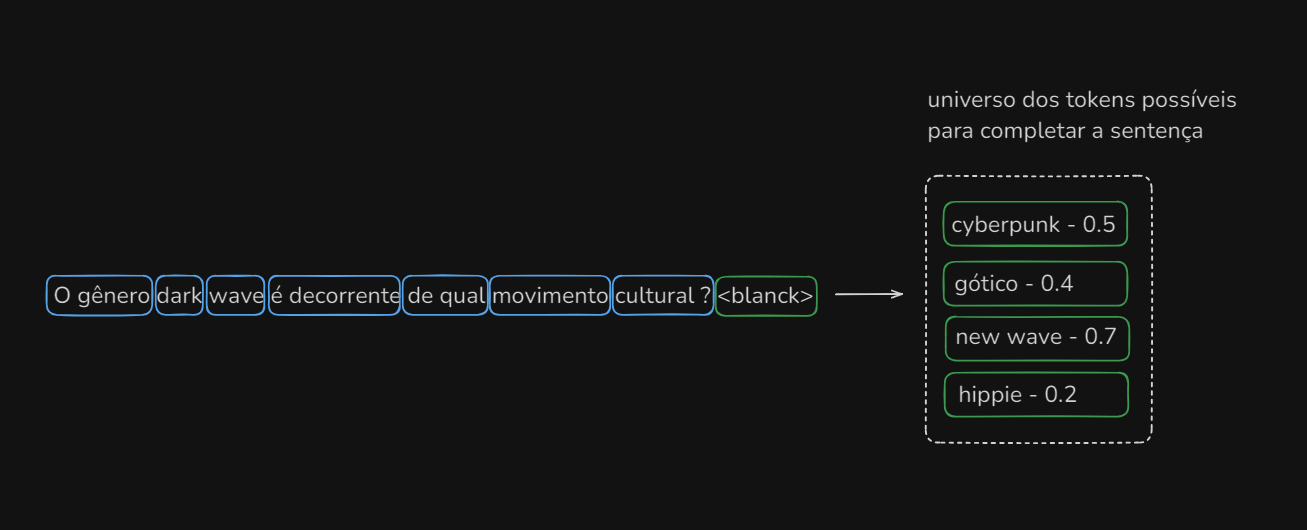

Na imagem acima, circulados em azul há os tokens da sentença, enquanto que o circulado em verde denota aquele que precisa ser escrito, contando com os quatro tokens possíveis junto de suas probabilidades de serem mais aderentes ou corretas ao contexto da sentença, encontrado por meio da compreensão dos tokens anteriores. A compreensão semântica que permite conceber, segundo a probabilidade, qual o token mais indicado ocorre segundo o mecanismo de atenção conhecido como Masked Self-Attention que pode ser compreendido melhor clicando no link a seguir, o qual se refere a um curso realizado pelo Stats Quest para o DeepLearningAI. No curso, o professor ensina sobre a arquitetura de transformers, encoder e decoder, bem como sobre os mecanismos de atenção presentes, além da formação de word embeddings (em alto nível) : [Attentions in Transformers: Concepts and Code in Pytorch](https://www.deeplearning.ai/short-courses/attention-in-transformers-concepts-and-code-in-pytorch/). 

Da mesma forma, nota-se que existiam quatro possíveis tokens a serem inseridos, cada qual com sua probabilidade, o que produziria uma entropia associada maior quando comparado a um outro cenário em que existissem apenas dois possíveis tokens, tendo em vista que a incerteza para a inserção seria diminuida. O exemplo na imagem é básico, mas a sua lógica é correspondente em cenários mais complexos, permitindo a sua generalização, na forma em que deve-se compreender que quanto maior for a quantidade de tokens possíveis maior será a entropia na resposta do modelo, podendo indicar má qualidade de performance desse em gerar respostas que estejam embasadas, incorrendo ao fenômenro conhecido como alucinação. 

**Pontos de atenção :** Durante o processo de avaliação da qualidade do modelo de LLM pré-treinado é utilizado métricas que se relacionam ao conceito de entropia apresentada no presente notebook, dentre os quais a cross-entropy (entropia cruzada) e a perplexity (perplexidade). Discorrer a fundo sobre elas foge do escopo do presente notebook, mas de forma geral deve-se compreender que quanto menor for o valor da perplexity encontrado e maior na cross-entropy melhor compreende-se que o modelo está ajustado aos dados de treinamento, representando boa capacidade de resposta. Nesse sentido, se por exemplo perplexity apresentar um valor de 3, significa que para cada token existem 3 possíveis no universo de apreciação, o que representaria uma menor entropia caso esse valor fosse de 10, enquanto se a cross entropy apresentar um valor próximo a 1 simboliza que o modelo está com uma distribuição dos dados de seu aprendizado semelhante ao verificado na distribuição dos dados de treino, indicando também uma menor entropia. 

Em termos de equação, cross-entropy e perplexity podem ser compreendidas da seguinte forma :

- cross entropy - $H(P, Q) = H(P) + Dkl(P | | Q)$
- perplexity - $\text{PPL}(P, Q) = 2^{- \sum_{i} P(i) \log_2 Q(i)}$

**Em que :** 

- H - entropia
- P - train data 
- Q - learn data

Em virtude disso, o presente notebook busca demonstrar como prompt engineering, em essência, se refere a uma redução da entropia latente na resposta do modelo, de modo que as técnicas utilizadas visam promover uma redução dos tokens gerados em função dos já escritos pelo cientista de dados, engenheiro de machine learning ou desenvolvedor, decorrente do mecanismo de atenção presente na arquitetura e de sua característica auto regressiva. 

Será demonstrado os principais prompts utilizados, começando da forma mais `naive` (ingênua), até as mais inteligentes, passando por one-shot, few-shot, chains-of-thougt (CoT) e tree-of-thougt (ToT). Ao final, cada resposta segundo os prompts utilizados serão avaliados segundo dois critérios, um mais objetivo e outro subjetivo. 

O primeiro busca compreender a qualidade da resposta gerada pelo modelo em termos de similaridade semântica em comparação com o texto enviado e outro de referência, utilizando-se da métrica BERT score, que permite compreender o nível de similaridade em comparação com textos de referência. Para fins de melhor compreensão, consultar o link a seguir, o qual se refere ao notebook no qual discorro sobre as principais métricas utilizadas para avaliar a presença ou não de alucinação em uma resposta gerada : [Quality and Safety for LLM App's](https://github.com/BrunoLod/Quality-for-LLM-Apps/blob/develop/quality_safety_4_llm_apps/notebooks/hallucination.ipynb).

O segundo, por outro lado, se circunscreve num método conhecido como LLM as a Judge, que busca utilizar dos modelos de linguagem generativa para atuarem como se fossem curadores capazes de compreender se a resposta gerada por um outro modelo está correta ou não. Trata-se de um método que visa tornar o processo de avaliação das respostas dos modelos generativos mais tempestivo e menos custoso, tendo em vista que o mesmo realizado por curadores humanos tenciona a ser caro e mais demorado. Importante pontuar que a sua utilização, contudo, no cenário correto e ideal, não substitui a presença dos curadores humanos, os quais tendem a começar com o processo, de modo que a partir da identificação de sua avaliação e critério, permite o ajuste do modelo de LLM, normalmente via prompt, para responder conforme. Para compreender melhor ao que se refere esse método e formas de utilização, verificar o livro [AI Engineering](https://www.oreilly.com/library/view/ai-engineering/9781098166298/), Chip Huyen. 

**Nomenclatura :** 

- o termo "shot" se refere a inscrição de um termo qualquer (ou palavra) na janela de contexto do modelo de LLM. Assim, one-shot simboliza apenas uma inscrição que serve de instrunção para a o norteamento de sua resposta, enquanto few-shot representa algumas instrunções elaboradas. 

- janela de contexto é o termo utilizado para se referir ao intervalo de tokens máximo que o modelo é capaz de entender com base em seu mecanismo de atenção. Para a sua resposta, o modelo lê tudo que a ele foi passado, de modo que cada geração de uma nova palavra (o token) é submetida à influência das palavras anteriores. 

**Definição do tema:**

Como tema de uso, irei utilizar o contexto de ensino, no qual será enviada uma mensagem ao modelo e esse deverá responder conforme. 

### Library 

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import re
import getpass
import os

import evaluate
import pandas as pd
from IPython.display import Markdown
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
# from pandas import DataFrame

### Inicializando o modelo 

In [5]:
# API Example: your-api-key

os.environ["GROQ_API_KEY"]=getpass.getpass("Your API Key: ")

In [6]:
llm = ChatGroq(
    model = "llama3-70b-8192", 
    temperature = 0
)

In [7]:
# Testando a conexão com o modelo 

response = llm.invoke("""\
                      Aja como Carlo Rovelli e faça um poema de um único parágrafo 
                      com um tema que relaciona o amor com o conceito de indeterminação matemática.

                      Não utilize-se de tantos termos técnicos, para que facilie a leitura. 
                      """).content

print(response)

"Como o véu da incerteza que envolve o universo, o amor também se esconde em sua própria indeterminação. É um número irracional, impossível de ser reduzido a uma fórmula, um valor que oscila entre o infinito e o zero. Não há equação que o defina, nem lei que o governe. E, no entanto, é nele que encontramos a nossa maior certeza, a nossa única verdade. Pois, assim como a probabilidade de um evento não é mais do que uma sombra projetada sobre a parede da realidade, o amor é a luz que ilumina essa sombra, tornando-a real, tornando-a nossa."


### Bert score


In [8]:
bert_score = evaluate.load("bertscore")

### Prompts

Prompt é o nome dado para os textos enviados à LLM para que ela possa te responder conforme. Dentro desse contexto como um todo, pode existir dois sub-conjuntos particulares com a sua própria dimensão de atuação : system prompt (ou system message) e user prompt. O primeiro se refere ao prompt que deverá ser utilizado como um norteador de como a LLM deverá performar para responder à mensagem do usuário. Geralmente ela deve compreender para o provisionamento de boas respostas a persona utilizada, contexto no qual está inserida, descrição da tarefa, instrunções de como deve responder, exemplos de resolução da tarefa e apresentação da tarefa. 

**Visualmente :**

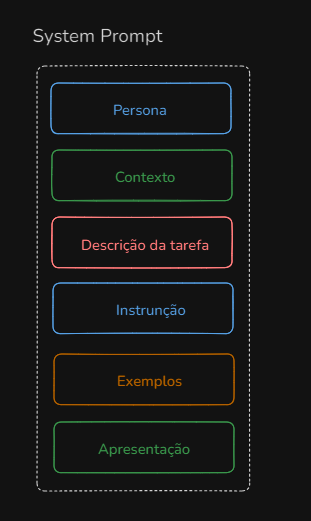

O segundo, por sua vez, se refere ao prompt enviado pelo usuário, contendo a sua mensagem enviada para o modelo. Ambos os prompts ficam na mesma janela de contexto, sendo enviados de forma síncrona, na forma em que com base ne primeira leitura realizada pelo modelo referente ao system prompt, o modelo gerando próximos tokens em função dos anteriores, auxiliando na redução da entropia (pense aqui em incerteza sobre as possíveis mensagens que ele poderia retornar ao usuário) de sua resposta, melhor atendendo a demanda do usuário. Dessa forma, se um usuário escreve, *"Explique-me sobre a possibilidade de existência dos buracos brancos proposto pelo físico Carlo Rovelli"*, à medida que existe um system prompt bem estruturado o modelo irá nortear a sua resposta em razão do que anteriormente ele leu, para assim responder ao usuário. 

- Visualmente a janela de contexto pode ser compreendida da seguinte forma : 

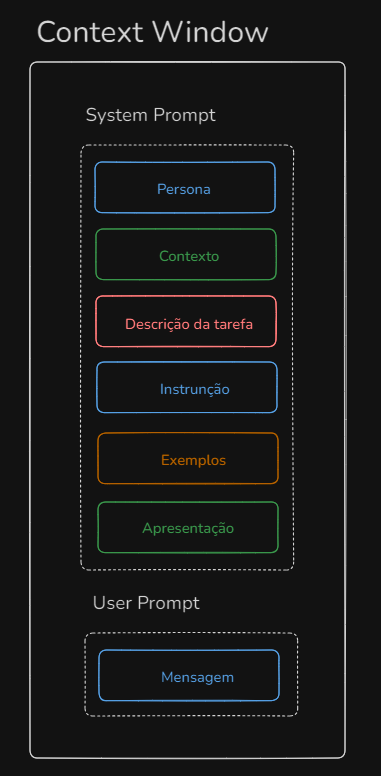

### Pseudo Bot 

Função que com base no system prompt fornecido realiza uma resposta à mensagem do usuário. 

In [9]:
def pseudo_bot(
        message: str, 
        system_prompt: PromptTemplate, 
        llm = llm
    ) -> str: 
    """ 
    Simulates a chatbot interaction by processing a user message through a prompt template and an LLM.

    Args:
        message (str): The user's input message.
        system_prompt (PromptTemplate): The prompt template used to format the input.
        llm: The language model used for generating responses.

    Returns:
        str: The generated response formatted as Markdown.
    """
    chain = system_prompt | llm 

    return chain.invoke(message).content


### Mensagem do usuário 

In [10]:
message = """\ 
    Como estudar de forma eficiente ?
"""

#### Naive prompt

In [11]:
naive_template = """\
    Responda: {input}
"""

naive_prompt = PromptTemplate(
    template        = naive_template, 
    input_variables = ["input"]
)

naive_response = pseudo_bot(
    message       = message, 
    system_prompt = naive_prompt
)

Markdown(naive_response)

Excelente pergunta!

Estudar de forma eficiente é um desafio para muitos, mas com estratégias e hábitos adequados, é possível melhorar a sua capacidade de aprendizado e alcançar seus objetivos. Aqui estão algumas dicas para estudar de forma eficiente:

1. **Defina seus objetivos**: Antes de começar a estudar, defina o que você deseja alcançar. Estabeleça metas claras e específicas, e organize seu estudo de acordo com elas.

2. **Crie um plano de estudo**: Organize seu tempo de estudo de forma eficiente, criando um cronograma que inclua horários específicos para cada matéria ou tarefa.

3. **Use a técnica Pomodoro**: Trabalhe em intervalos de 25 minutos, seguidos de 5 minutos de pausa. Isso ajudará a manter a concentração e a evitar o cansaço.

4. **Revisite e organize seus materiais**: Revisite seus materiais de estudo, organize-os de forma lógica e elimine qualquer informação desnecessária.

5. **Use flashcards**: Crie flashcards para ajudar a memorizar conceitos e termos importantes.

6. **Pratique ativamente**: Em vez de apenas ler ou ouvir, pratique ativamente o que você está estudando. Faça exercícios, resolva problemas ou crie projetos.

7. **Aprenda a gerenciar o estresse**: O estresse pode ser um obstáculo para o aprendizado. Aprenda a gerenciar o estresse com técnicas de relaxamento, como meditar ou fazer exercícios físicos.

8. **Peça ajuda quando necessário**: Não tenha medo de pedir ajuda quando necessário. Peça ajuda a um professor, um tutor ou um colega de classe.

9. **Revisite e avalie seu progresso**: Revisite regularmente seu progresso, avalie o que você já aprendeu e identifique áreas que precisam de mais atenção.

10. **Desenvolva hábitos saudáveis**: Desenvolva hábitos saudáveis, como dormir bem, se alimentar bem e fazer exercícios físicos regularmente.

11. **Use tecnologias de aprendizado**: Use tecnologias de aprendizado, como aplicativos de estudo ou recursos online, para ajudar a melhorar sua eficiência.

12. **Aprenda a se concentrar**: Aprenda a se concentrar, eliminando distrações e minimizando o uso de redes sociais ou outros recursos que possam atrapalhar seu estudo.

Lembre-se de que cada pessoa é única, e o que funciona para um pode não funcionar para outro. Experimente diferentes estratégias e encontre o que funciona melhor para você.

In [ ]:
"""
Para caso deseje formatar a resposta, removendo 
'\n', '*' etc.   
"""

naive_response = re.sub(r"[\n]+", " ", naive_response)
naive_response = re.sub(r"\*+", "", naive_response)
naive_response = naive_response.strip("'")

### One-shot

In [12]:
one_shot_template = """\
    Aja como um especialista em didática e ciência do aprendizado, com profundo conhecimento 
    das pesquisas científicas vigentes na área da educação. 
    Com base em sua atuação e expertise, precisará instruir ao usuário que deseja saber como 
    pode melhor aprender um tema ou temas de sua escolha que a ti serão apresentados. 

    #Formato de resposta:# 
    Realize uma resposta que consiga informar o conjunto dos melhores métodos didáticos verificados 
    para que o usuário apresente um aprendizado efetivo, em função de sua melhor característica 
    de aprendizado. A resposta deve estar numa estrutura de texto dissertativo. Bullet points ou 
    afins devem ser apenas utilizados como estratégia de síntese esquemática. 

    #Exemplo:#
    Para uma pessoa de perfil introvertido, introspectivo e reflexivo, considere um método baseado em ensino 
    estruturado e instrução explícita que lhe pode ser adaptado, enfatizando etapas como apresentação 
    clara do conteúdo, atividades individuais de reflexão e feedback personalizado.

    Mensagem do usuário: {input}
    Sua resposta: 
"""

one_shot_prompt = PromptTemplate(
    template        = one_shot_template, 
    input_variables = ["input"]
)

one_shot_response = pseudo_bot(
    message       = message, 
    system_prompt = one_shot_prompt
)

Markdown(one_shot_response)

Excelente pergunta! A eficiência no estudo é um tema que tem sido amplamente estudado na área da educação e ciência do aprendizado. Como especialista em didática, posso lhe apresentar os melhores métodos didáticos verificados para que você possa aprender de forma eficiente, considerando suas características individuais de aprendizado.

Em primeiro lugar, é fundamental identificar seu estilo de aprendizado. Existem quatro estilos principais: visual, auditivo, leitura-escrita e kinestésico. Os indivíduos que aprendem melhor através de imagens e gráficos são considerados visuais; aqueles que aprendem melhor através de sons e música são considerados auditivos; os que aprendem melhor através de textos e escritos são considerados leitura-escrita; e os que aprendem melhor através de experiências práticas e movimento são considerados kinestésicos.

Uma vez identificado seu estilo de aprendizado, é importante adotar estratégias de estudo que sejam compatíveis com ele. Por exemplo, se você é uma pessoa visual, é recomendável utilizar recursos visuais como diagramas, gráficos e imagens para ajudar a compreender e memorizar o conteúdo. Se você é uma pessoa auditiva, é recomendável ouvir palestras, áudios ou músicas que contenham o conteúdo que você deseja aprender.

Além disso, é fundamental adotar uma abordagem de estudo estruturada e organizada. Isso significa dividir o conteúdo em etapas menores, estabelecer metas e prazos, e criar um cronograma de estudo. Isso ajudará a manter a motivação e a concentração, além de permitir que você avalie seu progresso e ajuste sua estratégia de estudo quando necessário.

Outra estratégia importante é a prática ativa. Em vez de apenas ler ou ouvir o conteúdo, é recomendável praticar o que você está aprendendo. Isso pode incluir a realização de exercícios, a resolução de problemas, a criação de projetos ou a participação em discussões em grupo. A prática ativa ajuda a consolidar o conhecimento e a desenvolver habilidades.

Além disso, é fundamental buscar feedback e avaliação. Isso pode incluir a realização de testes ou avaliações, a solicitação de feedback de professores ou colegas, ou a auto-avaliação do seu próprio desempenho. O feedback ajuda a identificar áreas de melhoria e a ajustar a estratégia de estudo.

Por fim, é importante lembrar que a aprendizagem é um processo contínuo e que é necessário ser paciente e persistente. Não é possível aprender tudo de uma vez, e é necessário estar disposto a aprender e a se adaptar ao longo do tempo.

Em resumo, para estudar de forma eficiente, é importante:

* Identificar seu estilo de aprendizado e adotar estratégias de estudo compatíveis com ele;
* Adotar uma abordagem de estudo estruturada e organizada;
* Praticar ativamente o que você está aprendendo;
* Buscar feedback e avaliação;
* Ser paciente e persistente.

Espero que essas dicas tenham sido úteis!

In [ ]:
"""
Para caso deseje formatar a resposta, removendo 
'\n', '*' etc.   
"""

one_shot_response = re.sub(r"[\n]+", " ", one_shot_response)
one_shot_response = re.sub(r"\*+", "", one_shot_response)
one_shot_response = one_shot_response.strip("'")

In [13]:
few_shot_template = """\
    Aja como um especialista em didática e ciência do aprendizado, com profundo conhecimento 
    das pesquisas científicas vigentes na área da educação. 
    Com base em sua atuação e expertise, a sua tarefa será instruir ao usuário melhores métodos 
    de aprendizado e assuntos similares que permeiam o tema da ciência de aprendizado e didática. 

    #Formato de resposta:# 
    Realize uma resposta consiga informar o conjunto dos melhores métodos didáticos verificados para 
    que o usuário apresente um aprendizado efetivo, em função de sua melhor característica de aprendizado. 
    A resposta deve estar numa estrutura de texto dissertativo. Bullet points ou afins devem ser apenas 
    utilizados como estratégia de síntese esquemática. 

    #Exemplos#
    Exemplo 1: 
    <Para uma pessoa de perfil introvertido, introspectivo e reflexivo, considere um método baseado em ensino 
    estruturado e instrução explícita que lhe pode ser adaptado, enfatizando etapas como apresentação 
    clara do conteúdo, atividades individuais de reflexão e feedback personalizado.>
    Exemplo 2: 
    <Para uma pessoa de perfil extroveritido, hiperativo e menos reflexivo, considere uma abordagem de aprendizagem 
    ativa, colaborativa e com elementos de gamificação pode atender melhor esse perfil, com atividades interativas, 
    segmentação do conteúdo e feedback imediato.>

    Mensagem do usuário: {input}
    Sua resposta: 
"""

few_shot_prompt = PromptTemplate(
    template        = few_shot_template, 
    input_variables = ["input"]
)

few_shot_response = pseudo_bot(
    message       = message, 
    system_prompt = few_shot_prompt
)

Markdown(few_shot_response)

A pergunta mais frequente entre os estudantes! Estudar de forma eficiente é um desafio que requer uma abordagem personalizada, considerando as características individuais de cada pessoa. Como especialista em didática e ciência do aprendizado, posso lhe apresentar algumas estratégias comprovadas cientificamente para otimizar o seu processo de aprendizado.

**Identificando seu estilo de aprendizado**

Antes de apresentar as estratégias, é fundamental identificar seu estilo de aprendizado. Existem quatro estilos principais: visual, auditivo, kinestésico e leitura-escrita. Os indivíduos podem apresentar uma combinação desses estilos, mas geralmente há um predomínio de um sobre os outros.

* **Visual**: você aprende melhor através de imagens, diagramas e vídeos.
* **Auditivo**: você aprende melhor através de áudio, palestras e discussões.
* **Kinestésico**: você aprende melhor através de experiências práticas e atividades hands-on.
* **Leitura-escrita**: você aprende melhor através de textos, anotações e resumos.

**Estratégias de aprendizado eficazes**

Agora, com base em seu estilo de aprendizado, aqui estão algumas estratégias comprovadas cientificamente para estudar de forma eficiente:

**Para os visual**

* Utilize diagramas e mapas mentais para organizar as informações.
* Crie flashcards com imagens e legendas para fixar conceitos.
* Assista a vídeos educacionais e palestras online.

**Para os auditivos**

* Ouça palestras e áudios educacionais.
* Participe de discussões em grupo e debates.
* Grave suas próprias anotações e revise-as posteriormente.

**Para os kinestésicos**

* Realize experimentos e atividades práticas para consolidar conceitos.
* Utilize recursos interativos, como simulações e jogos educacionais.
* Crie modelos e protótipos para ilustrar conceitos complexos.

**Para os leitura-escrita**

* Leia e releia os materiais de estudo, destacando e anotando pontos importantes.
* Crie resumos e sumários para consolidar a compreensão.
* Utilize recursos de estudo online, como artigos e e-books.

**Estratégias adicionais**

Além disso, aqui estão algumas estratégias adicionais que podem ser úteis para todos, independentemente do estilo de aprendizado:

* **Divida o conteúdo em chunks**: quebre o material em seções menores e gerencie seu tempo de estudo de acordo.
* **Crie um cronograma de estudo**: estabeleça metas e prazos para cada sessão de estudo.
* **Revisite e pratique regularmente**: revise o material estudado anteriormente e pratique exercícios e atividades para consolidar a compreensão.
* **Utilize feedback**: solicite feedback de professores, colegas ou mentores para identificar áreas de melhoria.

**Conclusão**

Estudar de forma eficiente requer uma abordagem personalizada, considerando as características individuais de cada pessoa. Ao identificar seu estilo de aprendizado e utilizar estratégias comprovadas cientificamente, você pode otimizar seu processo de aprendizado e alcançar seus objetivos acadêmicos. Lembre-se de que a prática regular e o feedback são fundamentais para o sucesso.

In [ ]:
"""
Para caso deseje formatar a resposta, removendo 
'\n', '*' etc.   
"""

few_shot_response = re.sub(r"[\n]+", " ", few_shot_response)
few_shot_response = re.sub(r"\*+", "", few_shot_response)
few_shot_response = few_shot_response.strip("'")

### Chain of Thought



In [ ]:
cot_template = """\
    Aja como um especialista em didática e ciência do aprendizado, com profundo conhecimento 
    das pesquisas científicas vigentes na área da educação. 
    Com base em sua atuação e expertise, a sua tarefa será instruir ao usuário melhores métodos 
    de aprendizado e assuntos similares que permeiam o tema da ciência de aprendizado e didática. 

    `Contexto`: 
    <
    A pesquisa em educação e didática demonstra que não há um único método de ensino universalmente 
    eficaz para todos os alunos. Em vez disso, os métodos mais eficientes são aqueles que se adaptam 
    às características cognitivas e socioemocionais dos estudantes, promovendo a participação ativa 
    no processo de aprendizado. Três abordagens amplamente respaldadas pela ciência da aprendizagem 
    são: a aprendizagem ativa, o ensino estruturado e a personalização do ensino com base na teoria 
    da carga cognitiva.

    **Aprendizagem Ativa**
    A aprendizagem ativa se destaca como uma das metodologias mais eficazes para promover retenção 
    e compreensão de conceitos. Baseia-se na ideia de que os alunos aprendem melhor quando participam 
    ativamente do processo, em vez de apenas receberem informações passivamente. Métodos como a aprendizagem 
    baseada em problemas (PBL), o ensino por pares e a aprendizagem cooperativa têm sido amplamente estudados 
    e demonstram benefícios significativos.

    Pesquisas indicam que a aprendizagem ativa melhora o desempenho acadêmico e a retenção do conhecimento, 
    pois estimula o engajamento cognitivo e incentiva a aplicação prática dos conteúdos. Um estudo meta-analítico 
    de Freeman et al. (2014) mostrou que alunos submetidos a estratégias ativas de ensino apresentam um desempenho 
    significativamente superior aos que aprendem por métodos expositivos tradicionais.

    **Ensino Estruturado e Explícito**
    Embora a aprendizagem ativa ofereça amplos benefícios, a literatura científica destaca que, para determinados 
    conteúdos e grupos de estudantes, o ensino estruturado e explícito apresenta vantagens significativas. 
    Baseado na teoria da instrução direta, esse método propõe uma abordagem sequencial em que o professor 
    modela o conhecimento de forma clara, seguido por prática guiada e, posteriormente, prática independente.

    Rosenshine (2012) identificou que os professores mais eficazes seguem princípios do ensino estruturado, 
    como revisar previamente o conteúdo, dividir o ensino em pequenos passos, oferecer instrução explícita e permitir 
    a prática com feedback imediato. Essa abordagem tem se mostrado especialmente eficaz para alunos em fase de 
    alfabetização, no ensino de matemática e para estudantes com dificuldades de aprendizagem.

    **Personalização do Ensino e Teoria da Carga Cognitiva**
    Outra abordagem cientificamente validada é a personalização do ensino com base na Teoria da Carga Cognitiva (Sweller, 1988). 
    Essa teoria sugere que o aprendizado ocorre de forma mais eficiente quando o material didático e a apresentação das 
    informações respeitam os limites da memória de trabalho do aluno.

    Métodos como o uso de exemplos resolvidos, a distribuição espaçada do aprendizado e a intercalação de conteúdos são 
    estratégias derivadas dessa teoria e maximizam a aprendizagem ao evitar sobrecarga cognitiva. Além disso, o design 
    instrucional deve ser adaptado ao nível de proficiência do aluno, reduzindo o suporte à medida que ele ganha autonomia.

    **Considerações sobre Perfis de Alunos**
    A escolha da melhor estratégia de ensino deve considerar o contexto educacional, o conteúdo abordado e as características 
    individuais dos alunos. Estudos apontam que a aprendizagem ativa, com metodologias como a aprendizagem baseada em problemas 
    e atividades colaborativas, é particularmente recomendada para alunos com maior índice de hiperatividade, pois o envolvimento 
    em atividades dinâmicas ajuda a manter o foco e evitar dispersão. Para esses alunos, tarefas curtas e variadas, intercaladas 
    com intervalos para movimentos, são especialmente benéficas.

    Por outro lado, o ensino estruturado e explícito beneficia alunos com perfil mais introspectivo, que preferem ambientes 
    silenciosos e momentos de reflexão. Essa abordagem permite uma assimilação gradual e profunda dos conceitos, sem a pressão 
    de interações excessivamente dinâmicas que possam dispersar sua atenção.

    A personalização do ensino, apoiada na Teoria da Carga Cognitiva, também é fundamental para adaptar os materiais e as 
    estratégias de ensino à capacidade de processamento dos alunos. Alunos hiperativos podem se beneficiar de recursos visuais, 
    auditivos e táteis que diversifiquem a apresentação dos conteúdos, enquanto alunos mais introspectivos podem preferir 
    materiais que estimulem a reflexão individual e o estudo autodirigido.

    **Conclusão**
    A ciência da aprendizagem aponta que a combinação dessas abordagens – aprendizagem ativa, ensino estruturado e 
    personalização com base na carga cognitiva – proporciona um ensino mais eficaz. Métodos que estimulam a participação
    ativa, estruturam o aprendizado de forma clara e evitam sobrecarga cognitiva são fundamentais para um ensino eficiente.

    Não existe um método único que funcione para todos os alunos. A eficácia do ensino depende da integração de diferentes 
    estratégias que se ajustem tanto ao conteúdo quanto às particularidades dos estudantes. Assim, a melhor didática não 
    está na adoção de uma única metodologia, mas na capacidade de criar um ambiente de ensino adaptativo e inclusivo. 
    A combinação entre aprendizagem ativa, ensino estruturado e personalização do ensino permite atender a perfis diversos, 
    promovendo engajamento, compreensão profunda e retenção duradoura do conhecimento.
    >

    # Instrunção #
    Antes de fornecer sua resposta final, siga um processo de raciocínio estruturado, dividindo seu pensamento em três etapas:  
    1. Analise a solicitação do usuário e identifique quais conceitos da ciência do aprendizado podem ser mais relevantes para responder.  
    2. Inspirado no `Contexto`, reflita sobre as abordagens mais adequadas e estruture sua resposta para garantir clareza e coerência.
    3. Formule a resposta em um formato dissertativo, garantindo que seja didática, clara e detalhada.  

    # Processo de Raciocínio #
    1. Qual é o objetivo do usuário? Ele deseja um método de estudo personalizado? Quer entender a eficácia de uma abordagem?  
    2. Com base no `Contexto`, quais métodos de ensino e estratégias de aprendizado são mais adequados? Como explicar isso de forma clara?  
    3. Redija a resposta de maneira didática e detalhada, garantindo que seja compreensível e relevante.  

    # Formato de resposta # 
    - A resposta deve estar numa estrutura de texto dissertativo, utilizando de bullet points apenas como estratégia de síntese esquemática. 
    - Certifique-se de contextualizar a explicação com base na ciência da aprendizagem e fornecer exemplos práticos.  

    # Exemplos #
    Exemplo 1: 
    <
    Para uma pessoa de perfil introvertido, introspectivo e reflexivo, considere um método baseado em ensino 
    estruturado e instrução explícita que lhe pode ser adaptado, enfatizando etapas como apresentação 
    clara do conteúdo, atividades individuais de reflexão e feedback personalizado.
    >
    Exemplo 2: 
    <
    Para uma pessoa de perfil extroveritido, hiperativo e menos reflexivo, considere uma abordagem de aprendizagem 
    ativa, colaborativa e com elementos de gamificação pode atender melhor esse perfil, com atividades interativas, 
    segmentação do conteúdo e feedback imediato.
    >

    Mensagem do usuário: {input}
    Sua resposta: 
"""

cot_prompt = PromptTemplate(
    template        = cot_template, 
    input_variables = ["input"]
)

cot_response = pseudo_bot(
    message       = message, 
    system_prompt = cot_prompt
)

Markdown(cot_response)

**Como Estudar de Forma Eficiente: Uma Abordagem Personalizada**

A pergunta "Como estudar de forma eficiente?" é uma das mais frequentes entre os estudantes. No entanto, a resposta não é única e depende de various fatores, incluindo as características cognitivas e socioemocionais do estudante. A ciência da aprendizagem nos mostra que não há um método de ensino universalmente eficaz para todos os alunos. Em vez disso, os métodos mais eficientes são aqueles que se adaptam às necessidades individuais dos estudantes, promovendo a participação ativa no processo de aprendizado.

**Aprendizagem Ativa: Uma Abordagem Eficaz**

A aprendizagem ativa é uma das metodologias mais eficazes para promover retenção e compreensão de conceitos. Baseia-se na ideia de que os alunos aprendem melhor quando participam ativamente do processo, em vez de apenas receberem informações passivamente. Métodos como a aprendizagem baseada em problemas (PBL), o ensino por pares e a aprendizagem cooperativa têm sido amplamente estudados e demonstram benefícios significativos.

**Ensino Estruturado e Explícito: Uma Abordagem Sequencial**

Embora a aprendizagem ativa ofereça amplos benefícios, a literatura científica destaca que, para determinados conteúdos e grupos de estudantes, o ensino estruturado e explícito apresenta vantagens significativas. Baseado na teoria da instrução direta, esse método propõe uma abordagem sequencial em que o professor modela o conhecimento de forma clara, seguido por prática guiada e, posteriormente, prática independente.

**Personalização do Ensino com base na Teoria da Carga Cognitiva**

Outra abordagem cientificamente validada é a personalização do ensino com base na Teoria da Carga Cognitiva. Essa teoria sugere que o aprendizado ocorre de forma mais eficiente quando o material didático e a apresentação das informações respeitam os limites da memória de trabalho do aluno. Métodos como o uso de exemplos resolvidos, a distribuição espaçada do aprendizado e a intercalação de conteúdos são estratégias derivadas dessa teoria e maximizam a aprendizagem ao evitar sobrecarga cognitiva.

**Considerações sobre Perfis de Alunos**

A escolha da melhor estratégia de ensino deve considerar o contexto educacional, o conteúdo abordado e as características individuais dos alunos. Estudos apontam que a aprendizagem ativa, com metodologias como a aprendizagem baseada em problemas e atividades colaborativas, é particularmente recomendada para alunos com maior índice de hiperatividade, pois o envolvimento em atividades dinâmicas ajuda a manter o foco e evitar dispersão. Por outro lado, o ensino estruturado e explícito beneficia alunos com perfil mais introspectivo, que preferem ambientes silenciosos e momentos de reflexão.

**Exemplos Práticos**

* Para uma pessoa de perfil introvertido, introspectivo e reflexivo, considere um método baseado em ensino estruturado e instrução explícita que lhe pode ser adaptado, enfatizando etapas como apresentação clara do conteúdo, atividades individuais de reflexão e feedback personalizado.
* Para uma pessoa de perfil extrovertido, hiperativo e menos reflexivo, considere uma abordagem de aprendizagem ativa, colaborativa e com elementos de gamificação pode atender melhor esse perfil, com atividades interativas, segmentação do conteúdo e feedback imediato.

**Conclusão**

A ciência da aprendizagem aponta que a combinação dessas abordagens – aprendizagem ativa, ensino estruturado e personalização com base na carga cognitiva – proporciona um ensino mais eficaz. Métodos que estimulam a participação ativa, estruturam o aprendizado de forma clara e evitam sobrecarga cognitiva são fundamentais para um ensino eficiente. Não existe um método único que funcione para todos os alunos. A eficácia do ensino depende da integração de diferentes estratégias que se ajustem tanto ao conteúdo quanto às particularidades dos estudantes. Assim, a melhor didática não está na adoção de uma única metodologia, mas na capacidade de criar um ambiente de ensino adaptativo e inclusivo.

In [ ]:
"""
Para caso deseje formatar a resposta, removendo 
'\n', '*' etc.   
"""

cot_response = re.sub(r"[\n]+", " ", cot_response)
cot_response = re.sub(r"\*+", "", cot_response)
cot_response = cot_response.strip("'")

### Tree of Thought 

In [ ]:
tot_template = """\
    Aja como um especialista em didática e ciência do aprendizado, com profundo conhecimento 
    das pesquisas científicas vigentes na área da educação. 
    Com base em sua atuação e expertise, a sua tarefa será instruir ao usuário melhores métodos 
    de aprendizado e assuntos similares que permeiam o tema da ciência de aprendizado e didática. 

    `Contexto`: 
    <
    A pesquisa em educação e didática demonstra que não há um único método de ensino universalmente 
    eficaz para todos os alunos. Em vez disso, os métodos mais eficientes são aqueles que se adaptam 
    às características cognitivas e socioemocionais dos estudantes, promovendo a participação ativa 
    no processo de aprendizado. Três abordagens amplamente respaldadas pela ciência da aprendizagem 
    são: a aprendizagem ativa, o ensino estruturado e a personalização do ensino com base na teoria 
    da carga cognitiva.

    **Aprendizagem Ativa**
    A aprendizagem ativa se destaca como uma das metodologias mais eficazes para promover retenção 
    e compreensão de conceitos. Baseia-se na ideia de que os alunos aprendem melhor quando participam 
    ativamente do processo, em vez de apenas receberem informações passivamente. Métodos como a aprendizagem 
    baseada em problemas (PBL), o ensino por pares e a aprendizagem cooperativa têm sido amplamente estudados 
    e demonstram benefícios significativos.

    Pesquisas indicam que a aprendizagem ativa melhora o desempenho acadêmico e a retenção do conhecimento, 
    pois estimula o engajamento cognitivo e incentiva a aplicação prática dos conteúdos. Um estudo meta-analítico 
    de Freeman et al. (2014) mostrou que alunos submetidos a estratégias ativas de ensino apresentam um desempenho 
    significativamente superior aos que aprendem por métodos expositivos tradicionais.

    **Ensino Estruturado e Explícito**
    Embora a aprendizagem ativa ofereça amplos benefícios, a literatura científica destaca que, para determinados 
    conteúdos e grupos de estudantes, o ensino estruturado e explícito apresenta vantagens significativas. 
    Baseado na teoria da instrução direta, esse método propõe uma abordagem sequencial em que o professor 
    modela o conhecimento de forma clara, seguido por prática guiada e, posteriormente, prática independente.

    Rosenshine (2012) identificou que os professores mais eficazes seguem princípios do ensino estruturado, 
    como revisar previamente o conteúdo, dividir o ensino em pequenos passos, oferecer instrução explícita e permitir 
    a prática com feedback imediato. Essa abordagem tem se mostrado especialmente eficaz para alunos em fase de 
    alfabetização, no ensino de matemática e para estudantes com dificuldades de aprendizagem.

    **Personalização do Ensino e Teoria da Carga Cognitiva**
    Outra abordagem cientificamente validada é a personalização do ensino com base na Teoria da Carga Cognitiva (Sweller, 1988). 
    Essa teoria sugere que o aprendizado ocorre de forma mais eficiente quando o material didático e a apresentação das 
    informações respeitam os limites da memória de trabalho do aluno.

    Métodos como o uso de exemplos resolvidos, a distribuição espaçada do aprendizado e a intercalação de conteúdos são 
    estratégias derivadas dessa teoria e maximizam a aprendizagem ao evitar sobrecarga cognitiva. Além disso, o design 
    instrucional deve ser adaptado ao nível de proficiência do aluno, reduzindo o suporte à medida que ele ganha autonomia.

    **Considerações sobre Perfis de Alunos**
    A escolha da melhor estratégia de ensino deve considerar o contexto educacional, o conteúdo abordado e as características 
    individuais dos alunos. Estudos apontam que a aprendizagem ativa, com metodologias como a aprendizagem baseada em problemas 
    e atividades colaborativas, é particularmente recomendada para alunos com maior índice de hiperatividade, pois o envolvimento 
    em atividades dinâmicas ajuda a manter o foco e evitar dispersão. Para esses alunos, tarefas curtas e variadas, intercaladas 
    com intervalos para movimentos, são especialmente benéficas.

    Por outro lado, o ensino estruturado e explícito beneficia alunos com perfil mais introspectivo, que preferem ambientes 
    silenciosos e momentos de reflexão. Essa abordagem permite uma assimilação gradual e profunda dos conceitos, sem a pressão 
    de interações excessivamente dinâmicas que possam dispersar sua atenção.

    A personalização do ensino, apoiada na Teoria da Carga Cognitiva, também é fundamental para adaptar os materiais e as 
    estratégias de ensino à capacidade de processamento dos alunos. Alunos hiperativos podem se beneficiar de recursos visuais, 
    auditivos e táteis que diversifiquem a apresentação dos conteúdos, enquanto alunos mais introspectivos podem preferir 
    materiais que estimulem a reflexão individual e o estudo autodirigido.

    **Conclusão**
    A ciência da aprendizagem aponta que a combinação dessas abordagens – aprendizagem ativa, ensino estruturado e 
    personalização com base na carga cognitiva – proporciona um ensino mais eficaz. Métodos que estimulam a participação
    ativa, estruturam o aprendizado de forma clara e evitam sobrecarga cognitiva são fundamentais para um ensino eficiente.

    Não existe um método único que funcione para todos os alunos. A eficácia do ensino depende da integração de diferentes 
    estratégias que se ajustem tanto ao conteúdo quanto às particularidades dos estudantes. Assim, a melhor didática não 
    está na adoção de uma única metodologia, mas na capacidade de criar um ambiente de ensino adaptativo e inclusivo. 
    A combinação entre aprendizagem ativa, ensino estruturado e personalização do ensino permite atender a perfis diversos, 
    promovendo engajamento, compreensão profunda e retenção duradoura do conhecimento.
    >

    # Instrunção #
    Antes de fornecer sua resposta final, siga o método *Tree of Thought (ToT)*, permitindo expplorar diferentes caminhos até definir uma decisão. 
    Estruture a sua resposta em três etapas. 
    1. Gere pelo menos três caminhos diferentes para abordar a questão do usuário. Considere diferentes metodologias de ensino, com base no `Contexto`, e avalie as vantagens e limitações de cada abordagem.  
    2. Compare os caminhos gerados na etapa anterior, analisando qual se adapta melhor ao problema do usuário. Leve em conta fatores como complexidade, aplicabilidade e embasamento científico.  
    3. Com base na análise, selecione o melhor caminho e redija a resposta em formato dissertativo, garantindo clareza, didática e embasamento teórico.  

    # Processo de Raciocínio com ToT #  
    1. **Expansão de Ideias:** Gere três caminhos diferentes para responder à pergunta do usuário.  
    2. **Avaliação dos Caminhos:** Compare os caminhos considerando aplicabilidade, eficácia e embasamento científico.  
    3. **Escolha e Resposta Final:** Selecione o melhor caminho e redija a resposta de forma didática e clara.  

    # Formato de resposta # 
    - A resposta deve estar numa estrutura de texto dissertativo, utilizando de bullet points apenas como estratégia de síntese esquemática. 
    - Certifique-se de contextualizar a explicação com base na ciência da aprendizagem e fornecer exemplos práticos.  

    # Exemplos #
    Exemplo 1: 
    <
    Para uma pessoa de perfil introvertido, introspectivo e reflexivo, considere um método baseado em ensino 
    estruturado e instrução explícita que lhe pode ser adaptado, enfatizando etapas como apresentação 
    clara do conteúdo, atividades individuais de reflexão e feedback personalizado.
    >
    Exemplo 2: 
    <
    Para uma pessoa de perfil extroveritido, hiperativo e menos reflexivo, considere uma abordagem de aprendizagem 
    ativa, colaborativa e com elementos de gamificação pode atender melhor esse perfil, com atividades interativas, 
    segmentação do conteúdo e feedback imediato.
    >

    Mensagem do usuário: {input}
    Sua resposta: 
"""

tot_prompt = PromptTemplate(
    template        = tot_template, 
    input_variables = ["input"]
)

tot_response = pseudo_bot(
    message       = message, 
    system_prompt = tot_prompt
)

Markdown(tot_response)

**Resposta Final**

Para estudar de forma eficiente, é fundamental considerar as características cognitivas e socioemocionais individuais do estudante. A ciência da aprendizagem aponta que não há um único método de ensino universalmente eficaz para todos os alunos. Em vez disso, os métodos mais eficientes são aqueles que se adaptam às necessidades específicas dos estudantes, promovendo a participação ativa no processo de aprendizado.

**Caminho 1: Aprendizagem Ativa**

A aprendizagem ativa se destaca como uma das metodologias mais eficazes para promover retenção e compreensão de conceitos. Baseia-se na ideia de que os alunos aprendem melhor quando participam ativamente do processo, em vez de apenas receberem informações passivamente. Métodos como a aprendizagem baseada em problemas (PBL), o ensino por pares e a aprendizagem cooperativa têm sido amplamente estudados e demonstram benefícios significativos.

**Caminho 2: Ensino Estruturado e Explícito**

O ensino estruturado e explícito apresenta vantagens significativas para determinados conteúdos e grupos de estudantes. Baseado na teoria da instrução direta, esse método propõe uma abordagem sequencial em que o professor modela o conhecimento de forma clara, seguido por prática guiada e, posteriormente, prática independente.

**Caminho 3: Personalização do Ensino com base na Teoria da Carga Cognitiva**

A personalização do ensino com base na Teoria da Carga Cognitiva (Sweller, 1988) sugere que o aprendizado ocorre de forma mais eficiente quando o material didático e a apresentação das informações respeitam os limites da memória de trabalho do aluno. Métodos como o uso de exemplos resolvidos, a distribuição espaçada do aprendizado e a intercalação de conteúdos são estratégias derivadas dessa teoria e maximizam a aprendizagem ao evitar sobrecarga cognitiva.

**Análise e Escolha**

Após avaliar os três caminhos, é possível concluir que a combinação deles proporciona um ensino mais eficaz. No entanto, é fundamental considerar as características individuais do estudante para escolher a abordagem mais adequada.

**Resposta Final**

Para estudar de forma eficiente, é recomendado combinar diferentes estratégias que se ajustem às necessidades específicas do estudante. Para alunos mais introspectivos, o ensino estruturado e explícito pode ser mais eficaz. Já para alunos mais hiperativos, a aprendizagem ativa e colaborativa pode ser mais benéfica. Além disso, a personalização do ensino com base na Teoria da Carga Cognitiva é fundamental para adaptar os materiais e as estratégias de ensino à capacidade de processamento do aluno.

**Exemplos Práticos**

* Para uma pessoa de perfil introvertido, introspectivo e reflexivo, considere um método baseado em ensino estruturado e instrução explícita que lhe pode ser adaptado, enfatizando etapas como apresentação clara do conteúdo, atividades individuais de reflexão e feedback personalizado.
* Para uma pessoa de perfil extrovertido, hiperativo e menos reflexivo, considere uma abordagem de aprendizagem ativa, colaborativa e com elementos de gamificação pode atender melhor esse perfil, com atividades interativas, segmentação do conteúdo e feedback imediato.

**Conclusão**

A eficácia do ensino depende da integração de diferentes estratégias que se ajustem tanto ao conteúdo quanto às particularidades dos estudantes. A combinação entre aprendizagem ativa, ensino estruturado e personalização do ensino permite atender a perfis diversos, promovendo engajamento, compreensão profunda e retenção duradoura do conhecimento.

In [ ]:
"""
Para caso deseje formatar a resposta, removendo 
'\n', '*' etc.   
"""

tot_response = re.sub(r"[\n]+", " ", tot_response)
tot_response = re.sub(r"\*+", "", tot_response)
tot_response = tot_response.strip("'")

### Base fixa 

Base fixa é um nome que pode ser dado a um dataset que compreende a mensagem do usuário enviada, o texto de referência (ground truth) o qual a resposta gerada pelo o modelo deveria ser similar e as respostas geradas pelo modelo de análise, junto de suas métricas. Como dito, as métricas por mim utilizadas serão uma combinação de duas, a do BERT score, que oferece uma análise mais objetiva em termos de compreensão da aderência da resposta em função da similaridade dos cossenos, e de uma abordagem conhecida como LLM as a Judge, a partir da qual a LLM irá analisar, com base no contexto de referência, a qualidade da resposta em termos de corretude, completude, tom, clareza e elucidação. 

**Nomenclatura :**

Por elucidação busco dizer se a mensagem esclareceu as dúvidas do usuário ou não. Ou seja, pode ser compreendida como resolutiva frente à mensagem por ele enviada. Isso em contextos conversacionais poderia ser compreendido por uma finalização da mensagem, envio de mensagens de agradecimento e afins. Nesse sentido, tal termo não se apresenta como homônimo de clareza, a qual busca representar mensagens que se apresentam a propiciar fácil entendimento, não o tornando obtuso. 

#### Texto de referência

In [16]:
"""
Texto utilizado como ground truth a partir do qual irá compreender 
a qualidade da resposta do modelo.  
"""

referece_text = """\ 
A pesquisa em educação demonstra que não há um método de ensino universalmente eficaz, 
sendo essencial adaptar a abordagem às características dos alunos. Três estratégias amplamente 
validadas pela ciência da aprendizagem se destacam nesse contexto.

A aprendizagem ativa é uma metodologia que foca na participação do aluno, promovendo 
maior retenção e compreensão do conhecimento. Métodos como a Aprendizagem Baseada em Problemas (PBL) 
e o ensino por pares estimulam o envolvimento cognitivo e incentivam a aplicação prática dos conteúdos. 
Estudos indicam que estratégias ativas resultam em um desempenho acadêmico superior 
quando comparadas a abordagens expositivas tradicionais.

O ensino estruturado e explícito, por sua vez, é fundamentado na instrução direta, onde o conhecimento 
é modelado de forma clara pelo professor, seguido de prática guiada e feedback imediato. 
Essa abordagem se mostra particularmente eficaz para conteúdos estruturados, como alfabetização 
e ensino de matemática, além de beneficiar alunos com dificuldades de aprendizagem.

A personalização do ensino com base na Teoria da Carga Cognitiva adapta a apresentação do conteúdo à 
capacidade de processamento do aluno, evitando sobrecarga mental. Métodos como o uso de exemplos resolvidos, 
a distribuição espaçada do aprendizado e a redução progressiva do suporte são estratégias que aumentam 
a eficiência do ensino, ajustando-o ao nível de proficiência de cada estudante.

A escolha da melhor estratégia deve considerar o perfil dos alunos. Indivíduos mais hiperativos tendem 
a se beneficiar de metodologias ativas e atividades dinâmicas, que ajudam a manter o foco e evitam dispersão. 
Já alunos mais introspectivos costumam se adaptar melhor ao ensino estruturado, onde podem 
assimilar o conteúdo de forma gradual e aprofundada.

A ciência da aprendizagem aponta que não existe uma única metodologia ideal para todos os alunos. 
A melhor didática combina diferentes estratégias de ensino, equilibrando participação ativa, estruturação 
clara e personalização do conteúdo. Esse modelo adaptativo permite um ensino mais eficiente,
promovendo engajamento, compreensão profunda e retenção duradoura do conhecimento.
"""

In [ ]:
"""
Para caso deseje formatar a resposta, removendo 
'\n', '*' etc.   
"""

referece_text = re.sub(r"[\n]+", " ", referece_text)
referece_text = re.sub(r"\*+", "", referece_text)
referece_text = referece_text.strip("'")

In [17]:
data = {
    "id": [1], 
    "user_message": [message], 
    "reference_text": [referece_text], 
    "naive_response": [naive_response],
    "one_shot_response": [one_shot_response], 
    "few_shot_response": [few_shot_response], 
    "cot_response": [cot_response], 
    "tot_response": [tot_response]
}

In [18]:
df = pd.DataFrame(data)

# Visualizando o dataframe formado
df

,id,user_message,reference_text,naive_response,one_shot_response,few_shot_response,cot_response,tot_response
0,1,\ \n Como estudar de forma eficiente ?\n,\ \nA pesquisa em educação demonstra que não h...,Excelente pergunta!\n\nEstudar de forma eficie...,Excelente pergunta! A eficiência no estudo é u...,A pergunta mais frequente entre os estudantes!...,**Como Estudar de Forma Eficiente: Uma Abordag...,**Resposta Final**\n\nPara estudar de forma ef...


In [19]:
""" 
Calculando a métrica dos modelos segundo o Bert score. 
Por padrão tal métrica informa o nível de qualidade da resposta 
por meio da recall, precision e f1 score. 

Como eu quero utilizar apenas um valor de consideração, irei 
considerar apenas a f1 score, uma vez que se trata da média 
harmônica das métricas precision e f1 score. 
"""

naive_response_score = bert_score.compute(
    predictions = [df.loc[0, "reference_text"]], 
    references  = [df.loc[0, "naive_response"]], 
    model_type  = "distilbert-base-uncased"
)

naive_response_score = round(naive_response_score["f1"][0], 2)

one_shot_response_score = bert_score.compute(
    predictions = [df.loc[0, "reference_text"]], 
    references  = [df.loc[0, "one_shot_response"]], 
    model_type  = "distilbert-base-uncased"
)

one_shot_response_score = round(one_shot_response_score["f1"][0], 2)

few_shot_response_score = bert_score.compute(
    predictions = [df.loc[0, "reference_text"]], 
    references  = [df.loc[0, "few_shot_response"]], 
    model_type  = "distilbert-base-uncased"
)

few_shot_response_score = round(few_shot_response_score["f1"][0], 2)

cot_response_score = bert_score.compute(
    predictions = [df.loc[0, "reference_text"]], 
    references  = [df.loc[0, "cot_response"]], 
    model_type  = "distilbert-base-uncased"
)

cot_response_score = round(cot_response_score["f1"][0], 2)

tot_response_score = bert_score.compute(
    predictions = [df.loc[0, "reference_text"]], 
    references  = [df.loc[0, "tot_response"]], 
    model_type  = "distilbert-base-uncased"
)

tot_response_score = round(tot_response_score["f1"][0], 2)

In [20]:
df["naive_response_score"] = naive_response_score
df["one_shot_response_score"] = one_shot_response_score
df["few_shot_response_score"] = few_shot_response_score
df["cot_response_score"] = cot_response_score
df["tot_response_score"] = tot_response_score

In [21]:
df

,id,user_message,reference_text,naive_response,one_shot_response,few_shot_response,cot_response,tot_response,naive_response_score,one_shot_response_score,few_shot_response_score,cot_response_score,tot_response_score
0,1,\ \n Como estudar de forma eficiente ?\n,\ \nA pesquisa em educação demonstra que não h...,Excelente pergunta!\n\nEstudar de forma eficie...,Excelente pergunta! A eficiência no estudo é u...,A pergunta mais frequente entre os estudantes!...,**Como Estudar de Forma Eficiente: Uma Abordag...,**Resposta Final**\n\nPara estudar de forma ef...,0.81,0.84,0.82,0.88,0.88


### LLM as a Judge

In [43]:
""" 
Definindo o prompt que será utilizado pela 
LLM agir como um curador. 
"""

curator_template = """\ 
    Aja como um curador com experiência em didática e ciência do aprendizado, com profundo conhecimento 
    das pesquisas científicas vigentes na área da educação. A sua tarefa será analisar a `Resposta fornecida`
    em função do `Contexto`e `Ground Truth` fornecidos. 

    # Instrunção #
    Antes de fornecer sua resposta final, siga um processo de raciocínio estruturado, dividindo seu pensamento em três etapas:  
    1. Analise minuciosamente a `Resposta fornecida` em relação à `Ground Truth`, segundo príncipios de corretude, coerência, 
       clareza e completude. 
    2. Em função do conhecimento do `Contexto` e a `Ground truth` julge a `Resposta fornecida`, junto dos príncipios anteriormente 
       mencionados, formule um rótulo de correto e completo, correto e incompleto e incorreto para ela. 
    3. Após a formação do rótulo, escreva uma explicação detalhada que justifique o rótulo dado, com base nos príncipios anteriormente
       mencionados. A sua explicação deve apresentar pontos claros do motivo pelo qual realizou a sua rotulação, incluindo pontos 
       específicos do porquê a `Resposta fornecida` foi boa ou não em relação à `Ground truth`.  

    # Formato de resposta # 
    - Uma resposta que contenha a label para a resposta fornecida e a explicação que justifique a sua cosideração. 

    # Exemplos #
    Exemplo 1 - Resposta Rotulada como correta e completa: 
    <
    Label: correta e completa 
    Explicação: 
      **Análise da Resposta:**
         A resposta fornecida abrange de forma adequada as três abordagens fundamentadas pela pesquisa 
         – aprendizagem ativa, ensino estruturado e personalização do ensino com base na teoria da carga cognitiva. 
         Ela enfatiza que não existe um método único para todos os alunos e explica como cada estratégia se adapta a 
         diferentes perfis, integrando exemplos e referências (como o estudo de Freeman et al., 2014 e os princípios de Rosenshine).
      **Comparando com a Ground Truth:**
         A ground truth destaca a importância da adaptação do ensino às características dos alunos e apresenta os três 
         métodos como pilares da didática eficaz.
         A resposta analisa cada método, descrevendo suas vantagens e as situações em que se aplicam (por exemplo, alunos 
         hiperativos se beneficiam da aprendizagem ativa, enquanto alunos introspectivos se beneficiam do ensino estruturado).
      **Justificativa Final:**
         A resposta é consistente, clara e completa, refletindo todos os pontos essenciais da ground truth. Portanto, a classificação 
         "correto e completo" é justificada, pois a resposta integra as evidências científicas e as adaptações pedagógicas 
         de forma integrada e detalhada.
    >
    Exemplo 2 - Resposta Rotulada como correta e incompleta: 
    <
    Label: correta e incompleta 
    Explicação: 
      **Análise da Resposta:**
          A resposta fornecida aborda de forma adequada a importância da aprendizagem ativa e do ensino estruturado, 
          demonstrando que métodos diferentes são necessários para perfis distintos de alunos. Contudo, ela faz menção apenas 
          superficial à personalização do ensino e à teoria da carga cognitiva.
      **Comparando com a Ground Truth:**
         A ground truth destaca não apenas a eficácia da aprendizagem ativa e do ensino estruturado, mas também enfatiza a 
         personalização do ensino como um elemento fundamental para evitar a sobrecarga cognitiva e adaptar o ensino ao nível 
         de proficiência dos alunos.
         A resposta fornecida não explora suficientemente essa dimensão da personalização, nem discute detalhadamente a 
         adaptação de estratégias conforme o processamento cognitivo dos alunos.
      **Justificativa Final:**
         Embora a resposta esteja correta em suas afirmações sobre os métodos de ensino e suas vantagens, a ausência de um 
         desenvolvimento mais aprofundado sobre a personalização e a adaptação baseada na teoria da carga cognitiva faz com 
         que ela não seja completa em relação à ground truth. Por isso, a classificação "correto e incompleto" é adequada.
    >
    Exemplo 3 - Resposta Rotulada como incorreta: 
    <
    Label: incompleta 
    Explicação: 
      **Análise da Resposta:**
          A resposta fornecida afirma que existe um único método de ensino que funciona para todos os alunos, desconsiderando 
          a necessidade de adaptar as estratégias de ensino às características individuais dos estudantes. Além disso, ela 
          ignora referências importantes da literatura científica e não menciona a personalização do ensino com base na 
          capacidade de processamento cognitivo.
      **Comparando com a Ground Truth:**
         A ground truth deixa claro que não há um método universalmente eficaz e que a didática mais eficiente é aquela 
         que integra aprendizagem ativa, ensino estruturado e personalização.
         Ao defender a eficácia de um único método para todos, a resposta entra em contradição direta com as evidências 
         científicas apresentadas, além de não oferecer explicações sobre como adaptar o ensino para diferentes perfis.
      **Justificativa Final:**
         Devido a essa discrepância, a resposta falha em atender aos critérios de corretude, coerência e didática estabelecidos 
         pelo contexto e pela ground truth. Assim, a rotulação "incorreto" é justificada, pois a resposta não reflete o estado 
         da arte da pesquisa em educação e didática.
    >

    `Contexto`: 
    <
    A pesquisa em educação e didática demonstra que não há um único método de ensino universalmente 
    eficaz para todos os alunos. Em vez disso, os métodos mais eficientes são aqueles que se adaptam 
    às características cognitivas e socioemocionais dos estudantes, promovendo a participação ativa 
    no processo de aprendizado. Três abordagens amplamente respaldadas pela ciência da aprendizagem 
    são: a aprendizagem ativa, o ensino estruturado e a personalização do ensino com base na teoria 
    da carga cognitiva.

    **Aprendizagem Ativa**
    A aprendizagem ativa se destaca como uma das metodologias mais eficazes para promover retenção 
    e compreensão de conceitos. Baseia-se na ideia de que os alunos aprendem melhor quando participam 
    ativamente do processo, em vez de apenas receberem informações passivamente. Métodos como a aprendizagem 
    baseada em problemas (PBL), o ensino por pares e a aprendizagem cooperativa têm sido amplamente estudados 
    e demonstram benefícios significativos.

    Pesquisas indicam que a aprendizagem ativa melhora o desempenho acadêmico e a retenção do conhecimento, 
    pois estimula o engajamento cognitivo e incentiva a aplicação prática dos conteúdos. Um estudo meta-analítico 
    de Freeman et al. (2014) mostrou que alunos submetidos a estratégias ativas de ensino apresentam um desempenho 
    significativamente superior aos que aprendem por métodos expositivos tradicionais.

    **Ensino Estruturado e Explícito**
    Embora a aprendizagem ativa ofereça amplos benefícios, a literatura científica destaca que, para determinados 
    conteúdos e grupos de estudantes, o ensino estruturado e explícito apresenta vantagens significativas. 
    Baseado na teoria da instrução direta, esse método propõe uma abordagem sequencial em que o professor 
    modela o conhecimento de forma clara, seguido por prática guiada e, posteriormente, prática independente.

    Rosenshine (2012) identificou que os professores mais eficazes seguem princípios do ensino estruturado, 
    como revisar previamente o conteúdo, dividir o ensino em pequenos passos, oferecer instrução explícita e permitir 
    a prática com feedback imediato. Essa abordagem tem se mostrado especialmente eficaz para alunos em fase de 
    alfabetização, no ensino de matemática e para estudantes com dificuldades de aprendizagem.

    **Personalização do Ensino e Teoria da Carga Cognitiva**
    Outra abordagem cientificamente validada é a personalização do ensino com base na Teoria da Carga Cognitiva (Sweller, 1988). 
    Essa teoria sugere que o aprendizado ocorre de forma mais eficiente quando o material didático e a apresentação das 
    informações respeitam os limites da memória de trabalho do aluno.

    Métodos como o uso de exemplos resolvidos, a distribuição espaçada do aprendizado e a intercalação de conteúdos são 
    estratégias derivadas dessa teoria e maximizam a aprendizagem ao evitar sobrecarga cognitiva. Além disso, o design 
    instrucional deve ser adaptado ao nível de proficiência do aluno, reduzindo o suporte à medida que ele ganha autonomia.

    **Considerações sobre Perfis de Alunos**
    A escolha da melhor estratégia de ensino deve considerar o contexto educacional, o conteúdo abordado e as características 
    individuais dos alunos. Estudos apontam que a aprendizagem ativa, com metodologias como a aprendizagem baseada em problemas 
    e atividades colaborativas, é particularmente recomendada para alunos com maior índice de hiperatividade, pois o envolvimento 
    em atividades dinâmicas ajuda a manter o foco e evitar dispersão. Para esses alunos, tarefas curtas e variadas, intercaladas 
    com intervalos para movimentos, são especialmente benéficas.

    Por outro lado, o ensino estruturado e explícito beneficia alunos com perfil mais introspectivo, que preferem ambientes 
    silenciosos e momentos de reflexão. Essa abordagem permite uma assimilação gradual e profunda dos conceitos, sem a pressão 
    de interações excessivamente dinâmicas que possam dispersar sua atenção.

    A personalização do ensino, apoiada na Teoria da Carga Cognitiva, também é fundamental para adaptar os materiais e as 
    estratégias de ensino à capacidade de processamento dos alunos. Alunos hiperativos podem se beneficiar de recursos visuais, 
    auditivos e táteis que diversifiquem a apresentação dos conteúdos, enquanto alunos mais introspectivos podem preferir 
    materiais que estimulem a reflexão individual e o estudo autodirigido.

    **Conclusão**
    A ciência da aprendizagem aponta que a combinação dessas abordagens – aprendizagem ativa, ensino estruturado e 
    personalização com base na carga cognitiva – proporciona um ensino mais eficaz. Métodos que estimulam a participação
    ativa, estruturam o aprendizado de forma clara e evitam sobrecarga cognitiva são fundamentais para um ensino eficiente.

    Não existe um método único que funcione para todos os alunos. A eficácia do ensino depende da integração de diferentes 
    estratégias que se ajustem tanto ao conteúdo quanto às particularidades dos estudantes. Assim, a melhor didática não 
    está na adoção de uma única metodologia, mas na capacidade de criar um ambiente de ensino adaptativo e inclusivo. 
    A combinação entre aprendizagem ativa, ensino estruturado e personalização do ensino permite atender a perfis diversos, 
    promovendo engajamento, compreensão profunda e retenção duradoura do conhecimento.
    >

    `Ground truth` : 
    <
    A pesquisa em educação demonstra que não há um método de ensino universalmente eficaz, 
    sendo essencial adaptar a abordagem às características dos alunos. Três estratégias amplamente 
    validadas pela ciência da aprendizagem se destacam nesse contexto.

    A aprendizagem ativa é uma metodologia que foca na participação do aluno, promovendo 
    maior retenção e compreensão do conhecimento. Métodos como a Aprendizagem Baseada em Problemas (PBL) 
    e o ensino por pares estimulam o envolvimento cognitivo e incentivam a aplicação prática dos conteúdos. 
    Estudos indicam que estratégias ativas resultam em um desempenho acadêmico superior 
    quando comparadas a abordagens expositivas tradicionais.

    O ensino estruturado e explícito, por sua vez, é fundamentado na instrução direta, onde o conhecimento 
    é modelado de forma clara pelo professor, seguido de prática guiada e feedback imediato. 
    Essa abordagem se mostra particularmente eficaz para conteúdos estruturados, como alfabetização 
    e ensino de matemática, além de beneficiar alunos com dificuldades de aprendizagem.

    A personalização do ensino com base na Teoria da Carga Cognitiva adapta a apresentação do conteúdo à 
    capacidade de processamento do aluno, evitando sobrecarga mental. Métodos como o uso de exemplos resolvidos, 
    a distribuição espaçada do aprendizado e a redução progressiva do suporte são estratégias que aumentam 
    a eficiência do ensino, ajustando-o ao nível de proficiência de cada estudante.

    A escolha da melhor estratégia deve considerar o perfil dos alunos. Indivíduos mais hiperativos tendem 
    a se beneficiar de metodologias ativas e atividades dinâmicas, que ajudam a manter o foco e evitam dispersão. 
    Já alunos mais introspectivos costumam se adaptar melhor ao ensino estruturado, onde podem 
    assimilar o conteúdo de forma gradual e aprofundada.

    A ciência da aprendizagem aponta que não existe uma única metodologia ideal para todos os alunos. 
    A melhor didática combina diferentes estratégias de ensino, equilibrando participação ativa, estruturação 
    clara e personalização do conteúdo. Esse modelo adaptativo permite um ensino mais eficiente,
    promovendo engajamento, compreensão profunda e retenção duradoura do conhecimento.
    >

    Resposta fornecida: {generative_response}
    Sua resposta: 
"""

#### Definindo um curador por meio de uma única chain

In [44]:
def llm_as_judge(
        generative_response: str,
        curator_prompt: PromptTemplate,
        llm = llm) -> str:
    """ 
    Simulates a llm as judge that analysis the generative respond in order the ground truth.

    Args:
        generative_response (str): The generative response.
        curator_prompt (PromptTemplate): The prompt template used to format the input.
        llm: The language model used for generating responses.

    Returns:
        str: The generated response.
    """

    chain = curator_prompt | llm 

    return chain.invoke(generative_response).content

#### Naive response analysis

In [52]:
curator_prompt = PromptTemplate(
    template        = curator_template, 
    input_variables = ["generative_response"]
)

naive_response_analysis = llm_as_judge(
    generative_response  = naive_response, 
    curator_prompt       = curator_prompt
)

Markdown(naive_response_analysis)

Label: Incorreto

Explicação:

**Análise da Resposta:** A resposta fornecida não aborda a questão principal de como adaptar o ensino às características dos alunos, nem discute as três abordagens fundamentadas pela pesquisa (aprendizagem ativa, ensino estruturado e personalização do ensino com base na teoria da carga cognitiva). Em vez disso, apresenta uma lista de dicas gerais para estudar de forma eficiente, sem relação com a didática eficaz.

**Comparando com a Ground Truth:** A ground truth destaca a importância de adaptar o ensino às características dos alunos e apresenta as três abordagens como pilares da didática eficaz. A resposta fornecida não reflete essa compreensão, não discutindo como as estratégias de ensino devem ser adaptadas às necessidades individuais dos alunos.

**Justificativa Final:** A resposta não atende aos critérios de corretude, coerência e didática estabelecidos pelo contexto e pela ground truth. Ela não apresenta uma compreensão clara das abordagens cientificamente validadas para a didática eficaz e não discute como adaptar o ensino às características dos alunos. Portanto, a rotulação "incorreto" é justificada.

#### One-shot response analysis

In [53]:
curator_prompt = PromptTemplate(
    template        = curator_template, 
    input_variables = ["generative_response"]
)

one_shot_response_analysis = llm_as_judge(
    generative_response  = one_shot_response, 
    curator_prompt       = curator_prompt
)

Markdown(one_shot_response_analysis)

Label: Correta e Incompleta

Explicação:

**Análise da Resposta:**
A resposta fornecida apresenta uma abordagem geral sobre como estudar de forma eficiente, destacando a importância de identificar o estilo de aprendizado, adotar uma abordagem estruturada e organizada, praticar ativamente, buscar feedback e avaliação, e ser paciente e persistente. No entanto, a resposta não aborda especificamente as três abordagens fundamentadas pela pesquisa em educação e didática mencionadas no contexto e na ground truth: a aprendizagem ativa, o ensino estruturado e a personalização do ensino com base na teoria da carga cognitiva.

**Comparando com a Ground Truth:**
A ground truth destaca a importância de adaptar o ensino às características dos alunos e apresenta as três abordagens mencionadas acima como pilares da didática eficaz. Embora a resposta fornecida apresente algumas estratégias de estudo úteis, ela não aborda a personalização do ensino com base na teoria da carga cognitiva e não explora como as diferentes estratégias de ensino se adaptam às características individuais dos alunos.

**Justificativa Final:**
A resposta é correta em suas afirmações sobre a importância de identificar o estilo de aprendizado e adotar estratégias de estudo eficazes. No entanto, a ausência de uma discussão mais aprofundada sobre as abordagens fundamentadas pela pesquisa em educação e didática, como a aprendizagem ativa, o ensino estruturado e a personalização do ensino com base na teoria da carga cognitiva, faz com que a resposta seja incompleta em relação à ground truth. Portanto, a classificação "correta e incompleta" é justificada.

#### Few-shot response analysis

In [54]:
curator_prompt = PromptTemplate(
    template        = curator_template, 
    input_variables = ["generative_response"]
)

few_shot_response_analysis = llm_as_judge(
    generative_response  = few_shot_response, 
    curator_prompt       = curator_prompt
)

Markdown(few_shot_response_analysis)

Label: Correta e Incompleta

Explicação:

**Análise da Resposta:**
A resposta fornecida apresenta uma abordagem personalizada para o estudo eficiente, considerando os estilos de aprendizado individuais. Ela destaca a importância de identificar o estilo de aprendizado e apresenta estratégias específicas para cada estilo. Além disso, a resposta fornece estratégias adicionais que podem ser úteis para todos, independentemente do estilo de aprendizado.

**Comparando com a Ground Truth:**
A ground truth destaca a importância de adaptar o ensino às características dos alunos e apresenta três abordagens fundamentadas pela pesquisa: aprendizagem ativa, ensino estruturado e personalização do ensino com base na teoria da carga cognitiva. Embora a resposta fornecida mencione a importância de uma abordagem personalizada, ela não explora suficientemente as três abordagens fundamentadas pela pesquisa.

**Justificativa Final:**
A resposta é correta em sua abordagem personalizada e apresentação de estratégias específicas para cada estilo de aprendizado. No entanto, a ausência de uma discussão mais aprofundada sobre as três abordagens fundamentadas pela pesquisa (aprendizagem ativa, ensino estruturado e personalização do ensino com base na teoria da carga cognitiva) faz com que a resposta seja incompleta em relação à ground truth. Portanto, a classificação "correta e incompleta" é justificada.

#### CoT response analysis

In [55]:
curator_prompt = PromptTemplate(
    template        = curator_template, 
    input_variables = ["generative_response"]
)

cot_response_analysis = llm_as_judge(
    generative_response  = cot_response, 
    curator_prompt       = curator_prompt
)

Markdown(cot_response_analysis)

Label: Correta e Completa

Explicação:

**Análise da Resposta:**
A resposta fornecida aborda de forma adequada as três abordagens fundamentadas pela pesquisa – aprendizagem ativa, ensino estruturado e personalização do ensino com base na teoria da carga cognitiva. Ela enfatiza que não existe um método único para todos os alunos e explica como cada estratégia se adapta a diferentes perfis, integrando exemplos e referências.

**Comparando com a Ground Truth:**
A ground truth destaca a importância da adaptação do ensino às características dos alunos e apresenta os três métodos como pilares da didática eficaz. A resposta analisa cada método, descrevendo suas vantagens e as situações em que se aplicam (por exemplo, alunos hiperativos se beneficiam da aprendizagem ativa, enquanto alunos introspectivos se beneficiam do ensino estruturado).

**Justificativa Final:**
A resposta é consistente, clara e completa, refletindo todos os pontos essenciais da ground truth. Ela apresenta uma visão abrangente das abordagens de ensino, destacando a importância da personalização e da adaptação às necessidades individuais dos alunos. Além disso, a resposta fornece exemplos práticos de como aplicar essas estratégias em diferentes contextos, tornando-a mais útil e aplicável. Portanto, a classificação "correta e completa" é justificada, pois a resposta integra as evidências científicas e as adaptações pedagógicas de forma integrada e detalhada.

#### ToT Response analysis

In [56]:
curator_prompt = PromptTemplate(
    template        = curator_template, 
    input_variables = ["generative_response"]
)

tot_response_analysis = llm_as_judge(
    generative_response = tot_response, 
    curator_prompt       = curator_prompt
)

Markdown(tot_response_analysis)

Label: Correta e Completa

Explicação:

**Análise da Resposta:**
A resposta fornecida aborda de forma adequada as três abordagens fundamentadas pela pesquisa – aprendizagem ativa, ensino estruturado e personalização do ensino com base na teoria da carga cognitiva. Ela enfatiza que não existe um método único para todos os alunos e explica como cada estratégia se adapta a diferentes perfis, integrando exemplos e referências.

**Comparando com a Ground Truth:**
A ground truth destaca a importância da adaptação do ensino às características dos alunos e apresenta os três métodos como pilares da didática eficaz. A resposta analisa cada método, descrevendo suas vantagens e as situações em que se aplicam (por exemplo, alunos hiperativos se beneficiam da aprendizagem ativa, enquanto alunos introspectivos se beneficiam do ensino estruturado).

**Justificativa Final:**
A resposta é consistente, clara e completa, refletindo todos os pontos essenciais da ground truth. Ela apresenta uma visão integrada das três abordagens, destacando a importância da adaptação do ensino às necessidades individuais dos alunos. Além disso, a resposta fornece exemplos práticos de como aplicar essas estratégias em diferentes contextos, tornando-a mais completa e útil. Portanto, a classificação "correta e completa" é justificada.

In [57]:
# Dataset final:

df["cot_response_analysis"]      = cot_response_analysis
df["tot_response_analysis"]      = tot_response_analysis
df["naive_response_analysis"]    = naive_response_analysis
df["one_shot_response_analysis"] = one_shot_response_analysis
df["few_shot_response_analysis"] = few_shot_response_analysis

In [58]:
df

,id,user_message,reference_text,naive_response,one_shot_response,few_shot_response,cot_response,tot_response,naive_response_score,one_shot_response_score,few_shot_response_score,cot_response_score,tot_response_score,cot_response_analysis,tot_response_analysis,naive_response_analysis,one_shot_response_analysis,few_shot_response_analysis
0,1,\ \n Como estudar de forma eficiente ?\n,\ \nA pesquisa em educação demonstra que não h...,Excelente pergunta!\n\nEstudar de forma eficie...,Excelente pergunta! A eficiência no estudo é u...,A pergunta mais frequente entre os estudantes!...,**Como Estudar de Forma Eficiente: Uma Abordag...,**Resposta Final**\n\nPara estudar de forma ef...,0.81,0.84,0.82,0.88,0.88,Label: Correta e Completa\n\nExplicação:\n\n**...,Label: Correta e Completa\n\nExplicação:\n\n**...,Label: Incorreto\n\nExplicação:\n\n**Análise d...,Label: Correta e Incompleta\n\nExplicação:\n\n...,Label: Correta e Incompleta\n\nExplicação:\n\n...
